In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load cleaned data
df = pd.read_csv('../data/processed/housing_cleaned.csv')

print(df.shape)
df.head()

(1458, 75)


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,12,2008,WD,Normal,250000


In [2]:
#create new features

#Total area
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

#Total bathrooms
df['TotalBath'] = (df['FullBath'] + df['HalfBath'] * 0.5 +
                   df['BsmtFullBath'] + df['BsmtHalfBath'] * 0.5)

#House age when sold
df['HouseAge'] = df['YrSold'] - df['YearBuilt']

#was it remodeled?
df['IsRemodeled'] = (df['YearRemodAdd'] != df['YearBuilt']).astype(int)

df[['TotalSF', 'TotalBath', 'HouseAge', 'IsRemodeled']].head()

,TotalSF,TotalBath,HouseAge,IsRemodeled
0,2566,3.5,5,0
1,2524,2.5,31,0
2,2706,3.5,7,1
3,2473,2.0,91,1
4,3343,3.5,8,0


In [3]:
# calculate skewness of all numerical columns
numerical_cols = df.select_dtypes(include=['number']).columns
skewness = df[numerical_cols].skew().sort_values(ascending=False)

# show highly skewed columns (skew > 0.75 is considered high)
highly_skewed = skewness[skewness > 0.75]
print(f"Highly skewed columns: {len(highly_skewed)}")
print(highly_skewed)

Highly skewed columns: 22
MiscVal          24.460085
PoolArea         15.948945
LotArea          12.573925
3SsnPorch        10.297106
LowQualFinSF      9.004955
KitchenAbvGr      4.484883
BsmtFinSF2        4.251925
ScreenPorch       4.118929
BsmtHalfBath      4.100114
EnclosedPorch     3.087164
MasVnrArea        2.696329
OpenPorchSF       2.339829
SalePrice         1.881296
LotFrontage       1.548217
WoodDeckSF        1.545805
MSSubClass        1.407011
GrLivArea         1.010992
BsmtUnfSF         0.920903
1stFlrSF          0.887637
2ndFlrSF          0.812957
TotalSF           0.804321
BsmtFinSF1        0.764789
dtype: float64


In [4]:
skewed_cols = highly_skewed.index.tolist()
skewed_cols.remove('SalePrice')  # remove  target variable

# apply log transformation to reduce skewness
df[skewed_cols] = np.log1p(df[skewed_cols])

print(f"Transformed {len(skewed_cols)} columns!")

print("\nSkewness after transformation:")
df[skewed_cols].skew().sort_values(ascending=False).head(10)

Transformed 21 columns!

Skewness after transformation:


PoolArea         15.517685
3SsnPorch         7.729423
LowQualFinSF      7.454943
MiscVal           5.166779
BsmtHalfBath      3.929871
KitchenAbvGr      3.866269
ScreenPorch       3.147639
BsmtFinSF2        2.521222
EnclosedPorch     2.109967
MasVnrArea        0.506312
dtype: float64

SalePrice skewness after transform: 0.12


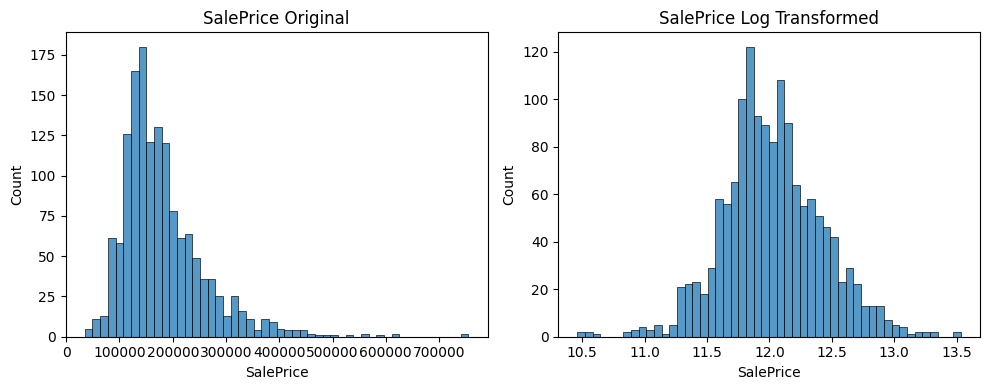

In [5]:
# transform target variable
df['SalePrice'] = np.log1p(df['SalePrice'])

print(f"SalePrice skewness after transform: {df['SalePrice'].skew():.2f}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(np.expm1(df['SalePrice']), bins=50)
plt.title('SalePrice Original')

plt.subplot(1, 2, 2)
sns.histplot(df['SalePrice'], bins=50)
plt.title('SalePrice Log Transformed')

plt.tight_layout()
plt.savefig('../outputs/01_saleprice_transform.png')
plt.show()

In [6]:
# create binary features for zero-inflated columns(ones which have very little effect even after log transform)
df['Has_Pool'] = (df['PoolArea'] > 0).astype(int)
df['Has_3SsnPorch'] = (df['3SsnPorch'] > 0).astype(int)
df['Has_Screen'] = (df['ScreenPorch'] > 0).astype(int)
df['Has_Enclosed'] = (df['EnclosedPorch'] > 0).astype(int)

print(df[['Has_Pool', 'Has_3SsnPorch', 'Has_Screen', 'Has_Enclosed']].sum())

Has_Pool           6
Has_3SsnPorch     24
Has_Screen       116
Has_Enclosed     208
dtype: int64


In [7]:
# drop original zero-inflated columns
df.drop(columns=['PoolArea', '3SsnPorch', 
                 'ScreenPorch', 'EnclosedPorch'], inplace=True)

print(df.shape)

(1458, 79)


In [8]:
# check how many zeros in remaining skewed columns
remaining_skewed = ['LowQualFinSF', 'MiscVal', 
                    'BsmtHalfBath', 'KitchenAbvGr', 'BsmtFinSF2']

for col in remaining_skewed:
    zeros = (df[col]==0).sum()
    pct = zeros/len(df)*100
    print(f"{col}: {zeros} zeros ({pct:.1f}%)")

LowQualFinSF: 1432 zeros (98.2%)
MiscVal: 1406 zeros (96.4%)
BsmtHalfBath: 1376 zeros (94.4%)
KitchenAbvGr: 1 zeros (0.1%)
BsmtFinSF2: 1291 zeros (88.5%)


In [9]:
# create binary features for zero-inflated columns
df['Has_LowQual'] = (df['LowQualFinSF'] > 0).astype(int)
df['Has_MiscVal'] = (df['MiscVal'] > 0).astype(int)
df['Has_BsmtHalf'] = (df['BsmtHalfBath'] > 0).astype(int)
df['Has_BsmtFin2'] = (df['BsmtFinSF2'] > 0).astype(int)

# drop originals
df.drop(columns=['LowQualFinSF', 'MiscVal', 
                 'BsmtHalfBath', 'BsmtFinSF2'], inplace=True)

print(df.shape)
print(f"Remaining skewness of KitchenAbvGr: {df['KitchenAbvGr'].skew():.2f}")

(1458, 79)
Remaining skewness of KitchenAbvGr: 3.87


In [10]:
# drop columns fully captured by new features (see 2nd block of notebook)
df.drop(columns=['TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
                 'FullBath', 'HalfBath', 
                 'BsmtFullBath'], inplace=True)
# BsmtHalfBath already dropped earlier!

print(df.shape)

(1458, 73)


In [11]:
#check categorical columns
cat_cols = df.select_dtypes(include=['str']).columns
print(f"Total categorical columns: {len(cat_cols)}")
print(cat_cols)

Total categorical columns: 38
Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
       'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
       'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='str')


In [12]:
# ordinal encoding - quality columns have natural order
# Poor=1, Fair=2, Average=3, Good=4, Excellent=5

quality_map = {
    'None': 0,  # no feature
    'Po': 1,  # Poor
    'Fa': 2, # Fair
    'TA': 3,  # Average/Typical
    'Gd': 4,  # Good
    'Ex': 5 # Excellent
}

# columns that use this quality scale
quality_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                'HeatingQC', 'KitchenQual', 'FireplaceQu',
                'GarageQual', 'GarageCond']

for col in quality_cols:
    df[col] = df[col].map(quality_map)

print(df[quality_cols].head())

   ExterQual  ExterCond  BsmtQual  BsmtCond  HeatingQC  KitchenQual  \
0          4          3       4.0       3.0          5            4   
1          3          3       4.0       3.0          5            3   
2          4          3       4.0       3.0          5            4   
3          3          3       3.0       4.0          4            4   
4          4          3       4.0       3.0          5            4   

   FireplaceQu  GarageQual  GarageCond  
0          NaN         3.0         3.0  
1          3.0         3.0         3.0  
2          3.0         3.0         3.0  
3          4.0         3.0         3.0  
4          3.0         3.0         3.0  


In [14]:
# fill remaining NaN in FireplaceQu with 0 (no fireplace)
df['FireplaceQu'] = df['FireplaceQu'].fillna(0)

# verify
print(df['FireplaceQu'].unique())

[0. 3. 4. 2. 5. 1.]


In [15]:
# other ordinal mappings
# BsmtExposure - basement exposure to outside
bsmt_exp_map = {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}
df['BsmtExposure'] = df['BsmtExposure'].map(bsmt_exp_map)

# BsmtFinType - basement finish type
bsmt_fin_map = {'None': 0, 'Unf': 1, 'LwQ': 2, 
                'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
df['BsmtFinType1'] = df['BsmtFinType1'].map(bsmt_fin_map)
df['BsmtFinType2'] = df['BsmtFinType2'].map(bsmt_fin_map)

# Functional - home functionality
func_map = {'Sal': 1, 'Sev': 2, 'Maj2': 3, 'Maj1': 4,
            'Mod': 5, 'Min2': 6, 'Min1': 7, 'Typ': 8}
df['Functional'] = df['Functional'].map(func_map)

# GarageFinish
garage_fin_map = {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}
df['GarageFinish'] = df['GarageFinish'].map(garage_fin_map)

# PavedDrive
paved_map = {'N': 0, 'P': 1, 'Y': 2}
df['PavedDrive'] = df['PavedDrive'].map(paved_map)

print(f"Missing after ordinal encoding: {df[['BsmtExposure','BsmtFinType1','BsmtFinType2','Functional','GarageFinish','PavedDrive']].isnull().sum()}")

Missing after ordinal encoding: BsmtExposure    38
BsmtFinType1    37
BsmtFinType2    38
Functional       0
GarageFinish    81
PavedDrive       0
dtype: int64


In [16]:
# fill remaining NaN with 0 (no feature = 0)
cols_with_nan = ['BsmtExposure', 'BsmtFinType1', 
                 'BsmtFinType2', 'GarageFinish']
df[cols_with_nan] = df[cols_with_nan].fillna(0)

# verify
print(f"Missing after fix: {df[cols_with_nan].isnull().sum().sum()}")

Missing after fix: 0


In [17]:
# binary encoding - only 2 unique values

df['CentralAir'] = df['CentralAir'].map({'Y': 1, 'N': 0})
df['Street'] = df['Street'].map({'Pave': 1, 'Grvl': 0})

print(df[['CentralAir', 'Street']].value_counts())

CentralAir  Street
1           1         1359
0           1           93
1           0            4
0           0            2
Name: count, dtype: int64


In [18]:
#check remaining categorical columns
cat_remaining = df.select_dtypes(include=['str']).columns
print(f"Remaining categorical columns: {len(cat_remaining)}")
print(cat_remaining)

Remaining categorical columns: 21
Index(['MSZoning', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd',
       'Foundation', 'Heating', 'Electrical', 'GarageType', 'SaleType',
       'SaleCondition'],
      dtype='str')


In [19]:
#one hot encoding for remaining categorical columns

df=pd.get_dummies(df,
                  columns=cat_remaining,
                  drop_first=True,
                  dtype=int)  
print(f"Shape after one-hot encoding: {df.shape}")

Shape after one-hot encoding: (1458, 191)


In [20]:
# check range of numerical columns
df.describe().loc[['min', 'max']].T.head(20)

,min,max
MSSubClass,3.044522,5.252273
LotFrontage,3.091042,5.749393
LotArea,7.170888,12.279537
Street,0.000000,1.000000
OverallQual,1.000000,10.000000
OverallCond,1.000000,9.000000
YearBuilt,1872.000000,2010.000000
YearRemodAdd,1950.000000,2010.000000
MasVnrArea,0.000000,7.378384
ExterQual,2.000000,5.000000


In [22]:
# columns that need scaling:
# 1. not binary (range > 1)
# 2. not already small range (like ordinal 0-5)
# 3. large range values

# check range of all numerical columns
num_cols = df.select_dtypes(include=['number']).columns

ranges = pd.DataFrame({
    'min': df[num_cols].min(),
    'max': df[num_cols].max(),
    'range': df[num_cols].max() - df[num_cols].min()
}).sort_values(by='range', ascending=False)

# columns with large range → need scaling!
print(ranges.head(20))

                      min          max        range
GarageYrBlt      0.000000  2010.000000  2010.000000
GarageArea       0.000000  1390.000000  1390.000000
YearBuilt     1872.000000  2010.000000   138.000000
HouseAge         0.000000   136.000000   136.000000
YearRemodAdd  1950.000000  2010.000000    60.000000
TotRmsAbvGrd     2.000000    14.000000    12.000000
MoSold           1.000000    12.000000    11.000000
OverallQual      1.000000    10.000000     9.000000
OverallCond      1.000000     9.000000     8.000000
BedroomAbvGr     0.000000     8.000000     8.000000
BsmtUnfSF        0.000000     7.756623     7.756623
BsmtFinSF1       0.000000     7.691200     7.691200
MasVnrArea       0.000000     7.378384     7.378384
WoodDeckSF       0.000000     6.754604     6.754604
OpenPorchSF      0.000000     6.306275     6.306275
BsmtFinType1     0.000000     6.000000     6.000000
BsmtFinType2     0.000000     6.000000     6.000000
Functional       2.000000     8.000000     6.000000
LotArea     

In [23]:
from sklearn.preprocessing import StandardScaler

cols_to_scale = ['GarageYrBlt', 'GarageArea', 'YearBuilt',
                 'HouseAge', 'YearRemodAdd', 
                 'TotRmsAbvGrd', 'MoSold']

# initialize scaler
scaler = StandardScaler()

#fit_transform on our data
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

# verify mean≈0, std≈1
print(df[cols_to_scale].describe().loc[['mean','std']].T)

                      mean       std
GarageYrBlt  -9.624979e-17  1.000343
GarageArea    5.117077e-17  1.000343
YearBuilt     3.033696e-15  1.000343
HouseAge     -2.436703e-17  1.000343
YearRemodAdd  3.323664e-15  1.000343
TotRmsAbvGrd  2.022464e-16  1.000343
MoSold        5.117077e-17  1.000343


In [24]:
#separate features and target
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

#save
X.to_csv('../data/processed/housing_features.csv', index=False)
y.to_csv('../data/processed/housing_target.csv', index=False)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (1458, 190)
Target shape: (1458,)
